# Session 2 - Using a Deterministic Model for a Rough Inlet
*By Robin Furze and Joshua Montgomery*

Over the course of this workshop (session 3 onwards), the HMM will be defined and introduced. It can be confusing to identify what part of the maths is the HMM, and what is just maths specific to the model. For example, Reynolds equation is used for this scenario, but it not actually requried for the HMM.

Session 2 builds a deterministic model for the inlet problem. Determinisitc models are generally computationally prohibitive for tribological modelling, but in this instance the problem is simple enough that it will not be a problem. Through comparison with the model of session 4, it should be clear how to deploy the HMM into an existing model.


---
### Downloading the Necessary Packages

Many different solvers can be used. In this workshope, NGSOLVE is used. This is because it solves quickly and can be installed into a Google Colab environment. When the following code snippet may take a while to run initally, NGSOLVE will only need to be installed once.

In [15]:
try:
    import ngsolve
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/ngsolve-install-release-real.sh" -O "/tmp/ngsolve-install.sh" && bash "/tmp/ngsolve-install.sh"
    import ngsolve

from ngsolve import *
from ngsolve.webgui import Draw
from ngsolve.meshes import *
import matplotlib.pyplot as plt

from ngsolve.solvers import *
import numpy as np
from ngsolve.webgui import Draw
from netgen.meshing import *

---
### Inputs

Various parameters are arbitrarily defined for this example. Feel free to tweak these parameters.

In [16]:
## Physical Parameters
U = 2 #Fluid velocity (m/s)
eta = 0.1 # Fluid viscosity (Pa.s)
rho = 1 # Fluid density (kgm^-3)
h0 = 0.2 # Inital film thickness (m)
dhdx = 0.15 # Total reduction in film thickness across the inlet (m)
Ah = 10e-3 # Microscale roughness
lm = 5e-3 # Asperity distance (m)

# Newton solver tolerance (macro and micro)
Newton_tol = 1e-6

---
### Application of a 1D Mesh
A determinisitic solution requires that an extremely fine mesh is applied. This is so the applied microscale topgraphy can be resolved across the entire macroscale. As the problem is 1D, the mesh can still be feasibly resolved on Google Collab.

In [17]:
## Deterministic Meshing
Ne_deterministic = 10000 #Mesh elements
k = 1 # Order of elements

## Create Determinstic mesh
mesh_deterministic = Make1DMesh(Ne_deterministic)

---
### Setup the Problem

**hg_deterministic** - this function will map the variation in film thickness to the x parameter. Hence as x increases the film will decrease. This variable accounts for both microscale and macroscale variation in topography

**Solve_Macroscale** - this function will setup and solve the macroscale problem

In [18]:
def hg_determinstic(x, h0, dhdx):
  return h0 - dhdx*x + Ah * cos(2 * pi * x/lm)
import time

def Solve_Macroscale(mesh, hg, dQ, dP, H0):

  # Create a H1, order k space for the pressure field
  V_Macro = H1(mesh, order=k, dirichlet=".*") # All boundaries are set to dirichlet, p = 0
  p = V_Macro.TrialFunction()  # Pressure trial function
  v = V_Macro.TestFunction()   # Pressure test function
  p_Macro = GridFunction(V_Macro)  # solution
  film_Macro = GridFunction(V_Macro)
  dpdx_Macro = GridFunction(V_Macro)

  #Reynolds Equation
  a_Macro = BilinearForm(V_Macro)
  h = hg(x, H0, dhdx)
  a_Macro += (h**3 / (12 * eta)) * grad(p) * grad(v) * dx - (U/2) * h * grad(v) * dx
  if dQ is not None:
    dQ_gf = GridFunction(V_Macro)
    dQ_gf.vec.FV().NumPy()[:] = dQ  # load nodal values
    a_Macro += -dQ_gf * grad(v) * dx
  a_Macro.Assemble()

  #Solve the macroscale
  Newton(
      a_Macro,
      p_Macro,
      freedofs=V_Macro.FreeDofs(),
      maxit=100,
      maxerr=Newton_tol,
      inverse="sparsecholesky",
      printing=False,
  )
  film_Macro.Set(h)
  dpdx = grad(p_Macro)
  dpdx_Macro.Set(dpdx)

  #Construct array of zeta: {H, P, dPdX}
  zeta = np.array([film_Macro.vec.data, p_Macro.vec.data, dpdx_Macro.vec.data])
  return zeta, p_Macro



---
### Solve the Deterministic Problem

The deterministic model is solved and the solution is timed.

In [19]:
start = time.time()
zeta_deterministic,_ = Solve_Macroscale(mesh_deterministic, hg_determinstic, 0, 0, h0)
print(f'Execution time is {time.time() - start:.3} seconds')

Execution time is 0.114 seconds


---
### Smooth Solution

For later comparison, a smooth solution is calculated. This allows the impact of surface topography to be explored.

In [20]:
# Function for the macroscale without surface topgraphy
def hg(x, h0, dhdx):
  return h0 - dhdx*x

# Create mesh
mesh = Make1DMesh(Ne_deterministic)

# Solve
zeta,_ = Solve_Macroscale(mesh, hg, 0, 0, h0)
zeta_smooth = zeta

---
### Plotting deterministic data
Outputs of the deterministic model are compared to the smooth solution.

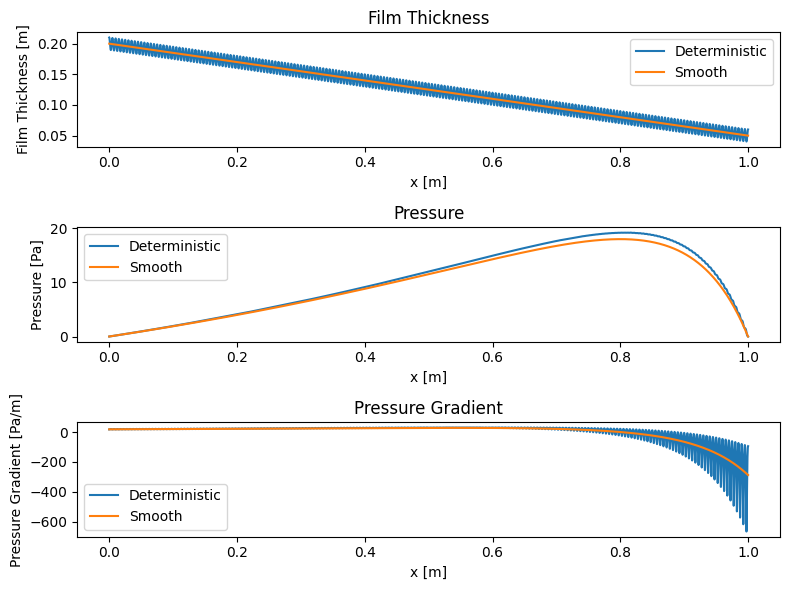

Maximum Pressure for Smooth Solution: 18.000, Maximum Pressure for Deterministic Solution: 19.221, Ratio rough/smooth 1.0678


In [21]:
zeta_smooth=zeta
x_vals_s = np.linspace(0, 1, np.size(zeta_smooth[0,:]))
x_vals_d = np.linspace(0, 1, np.size(zeta_deterministic[0,:]))

fig, axes = plt.subplots(3, 1, figsize=(8, 6))

axes[0].plot(x_vals_d, zeta_deterministic[0,:], label="Deterministic")
axes[0].plot(x_vals_s, zeta_smooth[0,:], label="Smooth")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("Film Thickness [m]")
axes[0].set_title("Film Thickness")
axes[0].legend()

axes[1].plot(x_vals_d, zeta_deterministic[1,:], label="Deterministic")
axes[1].plot(x_vals_s, zeta_smooth[1,:], label="Smooth")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("Pressure [Pa]")
axes[1].set_title("Pressure")
axes[1].legend()

axes[2].plot(x_vals_d, zeta_deterministic[2,:], label="Deterministic")
axes[2].plot(x_vals_s, zeta_smooth[2,:], label="Smooth")
axes[2].set_xlabel("x [m]")
axes[2].set_ylabel("Pressure Gradient [Pa/m]")
axes[2].set_title("Pressure Gradient")
axes[2].legend()

plt.tight_layout()
plt.show()
print(f'Maximum Pressure for Smooth Solution: {float(np.max(zeta_smooth[1,:])):.3f}, Maximum Pressure for Deterministic Solution: {float(np.max(zeta_deterministic[1,:])):.3f}, Ratio rough/smooth {float(np.max(zeta_deterministic[1,:]))/float(np.max(zeta_smooth[1,:])):.5}')